# RSNA Pneumonia Classification — DenseNet-121

End-to-end DenseNet-121 pipeline for binary pneumonia classification on the RSNA Stage 2 dataset.

The notebook covers preprocessing, model training, test evaluation, and Grad-CAM explainability. Model selection uses validation ROC-AUC, while the final classification threshold is selected on the validation set using F1 score.


## 1. Setup and Configuration


### 1.1 Imports and Reproducibility


In [1]:
from pathlib import Path
import json
import random
import shutil
import sys
import time

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import pydicom

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


### 1.2 Paths and Experiment Configuration


In [ ]:
DATA_DIR = Path("...".resolve())

TRAIN_IMAGE_DIR = (
    DATA_DIR
    / "stage_2_train_images"
    / "stage_2_train_images"
)

CLEAN_METADATA_PATH = DATA_DIR / "clean_classification_metadata.csv"
TRAIN_LABELS_PATH = DATA_DIR / "stage_2_train_labels.csv"

OUTPUT_DIR = Path("/kaggle/working/rsna_outputs/cnn")
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"

CACHE_DIR = Path("/kaggle/working/rsna_image_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4
LR_PATIENCE = 2
LR_FACTOR = 0.5

required_paths = {
    "clean metadata": CLEAN_METADATA_PATH,
    "training labels": TRAIN_LABELS_PATH,
    "training image directory": TRAIN_IMAGE_DIR,
}

for name, path in required_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"{name} not found: {path}")

print("Clean metadata:", CLEAN_METADATA_PATH)
print("Training labels:", TRAIN_LABELS_PATH)
print("Training images:", TRAIN_IMAGE_DIR)
print("Output directory:", OUTPUT_DIR)


Clean metadata: /kaggle/input/datasets/rutujapadmakarlahane/rsna-pneumonia-classification/clean_classification_metadata.csv
Training labels: /kaggle/input/datasets/rutujapadmakarlahane/rsna-pneumonia-classification/stage_2_train_labels.csv
Training images: /kaggle/input/datasets/rutujapadmakarlahane/rsna-pneumonia-classification/stage_2_train_images/stage_2_train_images
Output directory: /kaggle/working/rsna_outputs/cnn


## 2. Preprocessing


### 2.1 Load Metadata and Recreate the Patient-Level Split

The cleaned metadata is split at patient level using the same deterministic two-stage stratified 70/15/15 procedure for training, validation, and testing. The split files are saved with the experiment outputs.


In [3]:
clean_df = pd.read_csv(CLEAN_METADATA_PATH)
labels_df = pd.read_csv(TRAIN_LABELS_PATH)

required_columns = {
    "patientId",
    "Target",
    "detailed_class",
    "num_pneumonia_boxes",
}

missing_columns = required_columns - set(clean_df.columns)

if missing_columns:
    raise ValueError(
        f"Clean metadata is missing columns: {sorted(missing_columns)}"
    )

clean_df["image_filename"] = clean_df["patientId"].astype(str) + ".dcm"
clean_df["image_path"] = clean_df["image_filename"].apply(
    lambda name: str(TRAIN_IMAGE_DIR / name)
)

missing_images = clean_df.loc[
    ~clean_df["image_path"].map(lambda p: Path(p).is_file()),
    ["patientId", "image_path"],
]

if len(missing_images) != 0:
    raise FileNotFoundError(
        f"{len(missing_images)} DICOM files are missing."
    )

train_df, temp_df = train_test_split(
    clean_df,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=clean_df["Target"],
    random_state=SEED,
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["Target"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_ids = set(train_df["patientId"])
val_ids = set(val_df["patientId"])
test_ids = set(test_df["patientId"])

assert len(train_df) == 18678
assert len(val_df) == 4003
assert len(test_df) == 4003
assert not (train_ids & val_ids)
assert not (train_ids & test_ids)
assert not (val_ids & test_ids)
assert (train_ids | val_ids | test_ids) == set(clean_df["patientId"])

split_summary = pd.DataFrame([
    {
        "split": name,
        "samples": len(df),
        "negative": int((df["Target"] == 0).sum()),
        "positive": int((df["Target"] == 1).sum()),
        "positive_percentage": float(df["Target"].mean() * 100),
    }
    for name, df in [
        ("train", train_df),
        ("validation", val_df),
        ("test", test_df),
    ]
])

display(split_summary)

train_df.to_csv(OUTPUT_DIR / "train_metadata.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_metadata.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_metadata.csv", index=False)
split_summary.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)


,split,samples,negative,positive,positive_percentage
0,train,18678,14470,4208,22.529179
1,validation,4003,3101,902,22.533100
2,test,4003,3101,902,22.533100


### 2.2 DICOM Loading and Image Transforms

DICOM pixel values are scaled to `[0, 1]`, with `MONOCHROME1` inversion handled when required. Grayscale images are repeated across three channels for ImageNet-pretrained DenseNet-121. Training uses small rotations and translations; validation and test preprocessing are deterministic.


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def load_dicom_image(image_path):
    ds = pydicom.dcmread(image_path)
    image = ds.pixel_array.astype(np.float32)

    bits_stored = int(getattr(ds, "BitsStored", 8))
    scale = float((2 ** bits_stored) - 1)

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = scale - image

    image = np.clip(image / scale, 0.0, 1.0)
    return image.astype(np.float32)


class ToThreeChannelTensor:
    def __call__(self, image):
        tensor = torch.from_numpy(image).float().unsqueeze(0)
        return tensor.repeat(3, 1, 1)


train_transform = transforms.Compose([
    ToThreeChannelTensor(),
    transforms.RandomRotation(degrees=7),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    ToThreeChannelTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


### 2.3 Dataset and DataLoaders


In [5]:
from PIL import Image
from tqdm.auto import tqdm

for row in tqdm(
    clean_df.itertuples(index=False),
    total=len(clean_df),
    desc="Caching DICOM images",
):
    cache_path = CACHE_DIR / f"{row.patientId}.png"

    if cache_path.exists():
        continue

    ds = pydicom.dcmread(row.image_path)
    image = ds.pixel_array.astype(np.float32)

    bits_stored = int(getattr(ds, "BitsStored", 8))
    scale = float((2 ** bits_stored) - 1)

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = scale - image

    image = np.clip(image / scale, 0.0, 1.0)

    image = Image.fromarray(
        (image * 255).astype(np.uint8)
    )

    image = image.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BILINEAR,
    )

    image.save(cache_path)

clean_df["cached_image_path"] = clean_df["patientId"].apply(
    lambda patient_id: str(
        CACHE_DIR / f"{patient_id}.png"
    )
)

Caching DICOM images:   0%|          | 0/26684 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



In [6]:
# Add cached image paths to all split DataFrames
for df in [train_df, val_df, test_df]:
    df["cached_image_path"] = df["patientId"].apply(
        lambda patient_id: str(CACHE_DIR / f"{patient_id}.png")
    )

# Verify
print("Train:", "cached_image_path" in train_df.columns)
print("Val:", "cached_image_path" in val_df.columns)
print("Test:", "cached_image_path" in test_df.columns)

print("\nExample:")
print(train_df[["patientId", "cached_image_path"]].head())

Train: True
Val: True
Test: True

Example:
                              patientId  \
0  80bca6c8-5cdf-4528-85d6-aa6f3336664b   
1  0324368b-3c2f-464a-8b1a-f72113718c38   
2  f39dcdae-cc69-479f-8616-964e3f293bd5   
3  92dec024-edba-43be-973d-b2d58886e7c3   
4  502b6195-6248-4d78-abd3-328d20c17f1f   

                                   cached_image_path  
0  /kaggle/working/rsna_image_cache/80bca6c8-5cdf...  
1  /kaggle/working/rsna_image_cache/0324368b-3c2f...  
2  /kaggle/working/rsna_image_cache/f39dcdae-cc69...  
3  /kaggle/working/rsna_image_cache/92dec024-edba...  
4  /kaggle/working/rsna_image_cache/502b6195-6248...  


In [7]:
class RSNAPneumoniaDataset(Dataset):
    def __init__(self, metadata, transform=None):
        self.metadata = metadata.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]
        image = np.asarray(
            Image.open(row["cached_image_path"]),
            dtype=np.float32,
        ) / 255.0

        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(
            float(row["Target"]),
            dtype=torch.float32,
        )

        return {
            "image": image,
            "target": target,
            "patientId": row["patientId"],
        }


train_dataset = RSNAPneumoniaDataset(
    train_df,
    transform=train_transform,
)
val_dataset = RSNAPneumoniaDataset(
    val_df,
    transform=eval_transform,
)
test_dataset = RSNAPneumoniaDataset(
    test_df,
    transform=eval_transform,
)

generator = torch.Generator().manual_seed(SEED)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
    "prefetch_factor": 2 if NUM_WORKERS > 0 else None
}

if NUM_WORKERS > 0:
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=generator,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Training samples: 18678
Validation samples: 4003
Test samples: 4003
Training batches: 584
Validation batches: 126
Test batches: 126


### 2.4 Data Pipeline Check

A single batch is checked before model training to confirm tensor shape, type, and label range.


In [8]:
sample_batch = next(iter(train_loader))

print("Image batch shape:", tuple(sample_batch["image"].shape))
print("Image dtype:", sample_batch["image"].dtype)
print("Target shape:", tuple(sample_batch["target"].shape))
print(
    "Target values:",
    sorted(sample_batch["target"].unique().cpu().tolist()),
)

assert sample_batch["image"].shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
)
assert sample_batch["target"].min() >= 0
assert sample_batch["target"].max() <= 1


Image batch shape: (32, 3, 224, 224)
Image dtype: torch.float32
Target shape: (32,)
Target values: [0.0, 1.0]


## 3. Training


### 3.1 DenseNet-121 Model

The ImageNet classifier is replaced with a single output logit for binary classification. All model parameters remain trainable.


In [10]:
weights = DenseNet121_Weights.DEFAULT
model = densenet121(weights=weights)

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 1)
model = model.to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model: DenseNet-121")
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 152MB/s] 


Model: DenseNet-121
Total parameters: 6,954,881
Trainable parameters: 6,954,881


### 3.2 Loss, Optimizer, Scheduler, and Mixed Precision

Class imbalance is handled with `pos_weight` calculated from the training split only. AdamW is used for optimization, with validation ROC-AUC controlling the learning-rate scheduler and checkpoint selection.


In [11]:
negative_count = int((train_df["Target"] == 0).sum())
positive_count = int((train_df["Target"] == 1).sum())
POS_WEIGHT = negative_count / positive_count

pos_weight_tensor = torch.tensor(
    [POS_WEIGHT],
    dtype=torch.float32,
    device=DEVICE,
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda",
)

class_weight_summary = pd.DataFrame({
    "metric": [
        "training_negative_count",
        "training_positive_count",
        "BCE_pos_weight",
    ],
    "value": [
        negative_count,
        positive_count,
        POS_WEIGHT,
    ],
})

display(class_weight_summary)
class_weight_summary.to_csv(
    OUTPUT_DIR / "class_weight_summary.csv",
    index=False,
)


,metric,value
0,training_negative_count,14470.000000
1,training_positive_count,4208.000000
2,BCE_pos_weight,3.438688


### 3.3 Metric and Epoch Functions

Training metrics use a fixed threshold of `0.5`. ROC-AUC is threshold-independent and is used to select the best checkpoint.


In [12]:
def calculate_metrics(targets, probabilities, threshold=0.5):
    targets = np.asarray(targets).astype(int)
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        targets,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan

    return {
        "roc_auc": roc_auc_score(targets, probabilities),
        "average_precision": average_precision_score(
            targets,
            probabilities,
        ),
        "accuracy": accuracy_score(targets, predictions),
        "balanced_accuracy": balanced_accuracy_score(
            targets,
            predictions,
        ),
        "precision": precision_score(
            targets,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            targets,
            predictions,
            zero_division=0,
        ),
        "specificity": specificity,
        "npv": npv,
        "f1": f1_score(
            targets,
            predictions,
            zero_division=0,
        ),
        "mcc": matthews_corrcoef(targets, predictions),
        "brier_score": brier_score_loss(
            targets,
            probabilities,
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_probabilities = []

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        targets = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=DEVICE.type == "cuda",
        ):
            logits = model(images).squeeze(1)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        probabilities = torch.sigmoid(logits)
        all_targets.extend(
            targets.detach().cpu().numpy()
        )
        all_probabilities.extend(
            probabilities.detach().cpu().numpy()
        )

    epoch_loss = running_loss / len(loader.dataset)
    metrics = calculate_metrics(
        all_targets,
        all_probabilities,
    )

    return epoch_loss, metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_probabilities = []

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        targets = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=DEVICE.type == "cuda",
        ):
            logits = model(images).squeeze(1)
            loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)

        probabilities = torch.sigmoid(logits)
        all_targets.extend(targets.cpu().numpy())
        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

    epoch_loss = running_loss / len(loader.dataset)
    metrics = calculate_metrics(
        all_targets,
        all_probabilities,
    )

    return epoch_loss, metrics


### 3.4 Training Configuration


In [13]:
training_config = {
    "model": "DenseNet121",
    "pretraining": "ImageNet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "max_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "loss": "BCEWithLogitsLoss",
    "pos_weight": POS_WEIGHT,
    "model_selection_metric": "validation ROC-AUC",
    "threshold_selection": "maximum validation F1",
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "lr_scheduler": "ReduceLROnPlateau",
    "lr_patience": LR_PATIENCE,
    "lr_factor": LR_FACTOR,
    "mixed_precision": scaler.is_enabled(),
    "seed": SEED,
}

display(
    pd.DataFrame(
        training_config.items(),
        columns=["parameter", "value"],
    )
)

with open(
    OUTPUT_DIR / "training_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(training_config, f, indent=2)


,parameter,value
0,model,DenseNet121
1,pretraining,ImageNet
2,image_size,224
3,batch_size,32
4,max_epochs,15
5,learning_rate,0.0001
6,weight_decay,0.0001
7,optimizer,AdamW
8,loss,BCEWithLogitsLoss
9,pos_weight,3.438688


### 3.5 Train and Validate

Training history is written after every epoch. The best checkpoint is saved when validation ROC-AUC improves, and the last checkpoint is overwritten after every completed epoch so the run state is preserved.


In [14]:
BEST_MODEL_PATH = MODEL_DIR / "densenet121_best.pth"
LAST_MODEL_PATH = MODEL_DIR / "densenet121_last.pth"
HISTORY_PATH = OUTPUT_DIR / "training_history.csv"

best_val_auc = -np.inf
best_epoch = 0
epochs_without_improvement = 0
history = []

training_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
    )

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
    )

    scheduler.step(val_metrics["roc_auc"])

    epoch_minutes = (time.time() - epoch_start) / 60

    record = {
        "epoch": epoch,
        "learning_rate": current_lr,
        "train_loss": train_loss,
        "train_roc_auc": train_metrics["roc_auc"],
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_loss,
        "val_roc_auc": val_metrics["roc_auc"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "epoch_minutes": epoch_minutes,
    }

    history.append(record)
    pd.DataFrame(history).to_csv(
        HISTORY_PATH,
        index=False,
    )

    improved = val_metrics["roc_auc"] > best_val_auc

    if improved:
        best_val_auc = val_metrics["roc_auc"]
        best_epoch = epoch
        epochs_without_improvement = 0
        checkpoint_status = "best saved"
    else:
        epochs_without_improvement += 1
        checkpoint_status = (
            f"no improvement "
            f"({epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE})"
        )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "val_roc_auc": val_metrics["roc_auc"],
        "best_val_roc_auc": best_val_auc,
        "best_epoch": best_epoch,
        "epochs_without_improvement": epochs_without_improvement,
        "training_config": training_config,
        "history": history,
    }

    torch.save(checkpoint, LAST_MODEL_PATH)

    if improved:
        torch.save(checkpoint, BEST_MODEL_PATH)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"{epoch_minutes:.2f} min | "
        f"LR {current_lr:.2e}"
    )
    print(
        f"  Train | Loss {train_loss:.4f} | "
        f"AUC {train_metrics['roc_auc']:.4f} | "
        f"F1 {train_metrics['f1']:.4f} | "
        f"Recall {train_metrics['recall']:.4f}"
    )
    print(
        f"  Val   | Loss {val_loss:.4f} | "
        f"AUC {val_metrics['roc_auc']:.4f} | "
        f"F1 {val_metrics['f1']:.4f} | "
        f"Recall {val_metrics['recall']:.4f} | "
        f"{checkpoint_status}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

total_training_minutes = (time.time() - training_start) / 60

print(
    f"Training completed in "
    f"{total_training_minutes:.2f} minutes."
)
print("Best epoch:", best_epoch)
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")
print("Best checkpoint:", BEST_MODEL_PATH)
print("Last checkpoint:", LAST_MODEL_PATH)


Epoch 01/15 | 1.67 min | LR 1.00e-04
  Train | Loss 0.7519 | AUC 0.8470 | F1 0.5950 | Recall 0.7892
  Val   | Loss 0.6932 | AUC 0.8723 | F1 0.6216 | Recall 0.8215 | best saved
Epoch 02/15 | 1.67 min | LR 1.00e-04
  Train | Loss 0.6754 | AUC 0.8785 | F1 0.6278 | Recall 0.8211
  Val   | Loss 0.6865 | AUC 0.8777 | F1 0.6234 | Recall 0.8093 | best saved
Epoch 03/15 | 1.66 min | LR 1.00e-04
  Train | Loss 0.6435 | AUC 0.8900 | F1 0.6458 | Recall 0.8375
  Val   | Loss 0.6848 | AUC 0.8763 | F1 0.6295 | Recall 0.8193 | no improvement (1/4)
Epoch 04/15 | 1.67 min | LR 1.00e-04
  Train | Loss 0.6123 | AUC 0.9009 | F1 0.6608 | Recall 0.8474
  Val   | Loss 0.7145 | AUC 0.8766 | F1 0.6323 | Recall 0.7894 | no improvement (2/4)
Epoch 05/15 | 1.66 min | LR 1.00e-04
  Train | Loss 0.5646 | AUC 0.9153 | F1 0.6839 | Recall 0.8669
  Val   | Loss 0.7458 | AUC 0.8711 | F1 0.6161 | Recall 0.8237 | no improvement (3/4)
Epoch 06/15 | 1.66 min | LR 5.00e-05
  Train | Loss 0.4625 | AUC 0.9437 | F1 0.7377 | Reca

### 3.6 Training History


,epoch,learning_rate,train_loss,train_roc_auc,train_accuracy,train_precision,train_recall,train_f1,val_loss,val_roc_auc,val_accuracy,val_precision,val_recall,val_f1,epoch_minutes
0,1,0.00010,0.751890,0.846963,0.757951,0.477498,0.789211,0.595001,0.693241,0.872334,0.774669,0.500000,0.821508,0.621644,1.665544
1,2,0.00010,0.675404,0.878464,0.780651,0.508163,0.821055,0.627782,0.686501,0.877712,0.779665,0.506944,0.809313,0.623399,1.672414
2,3,0.00010,0.643488,0.889983,0.793019,0.525500,0.837452,0.645776,0.684796,0.876311,0.782663,0.511065,0.819290,0.629472,1.662458
3,4,0.00010,0.612344,0.900914,0.803994,0.541534,0.847433,0.660799,0.714517,0.876605,0.793155,0.527407,0.789357,0.632327,1.668081
4,5,0.00010,0.564600,0.915314,0.819467,0.564706,0.866920,0.683915,0.745809,0.871100,0.768673,0.492053,0.823725,0.616086,1.664360
5,6,0.00005,0.462475,0.943724,0.855498,0.624075,0.901854,0.737681,0.806515,0.868350,0.804647,0.549261,0.741685,0.631132,1.658440


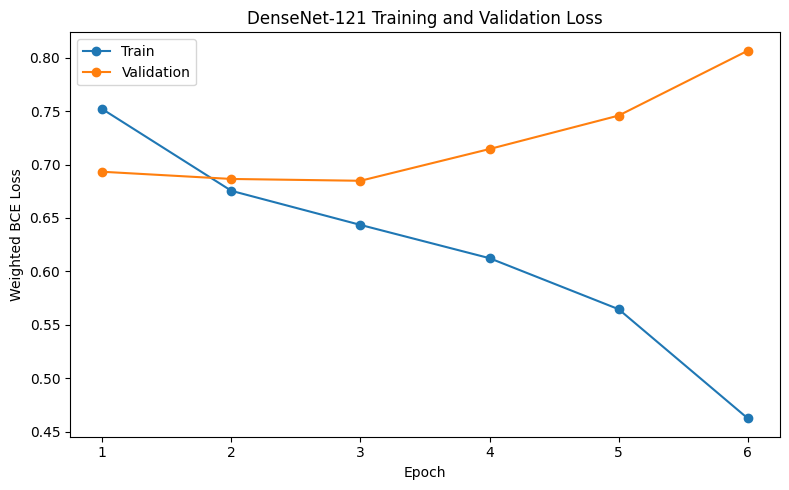

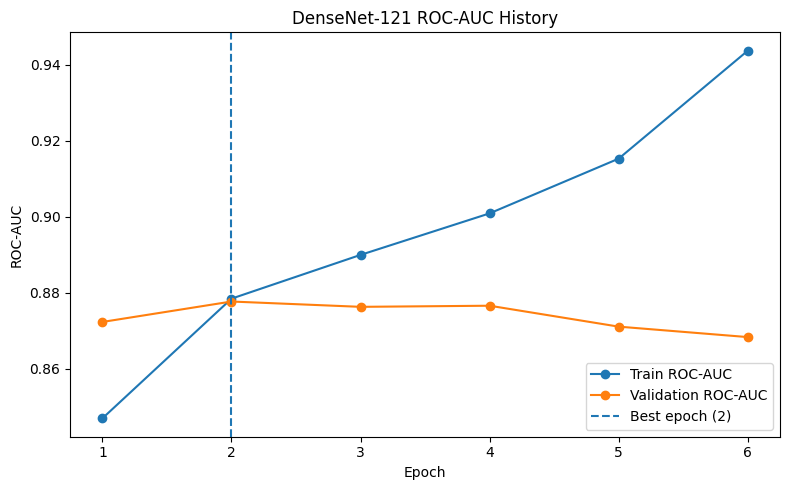

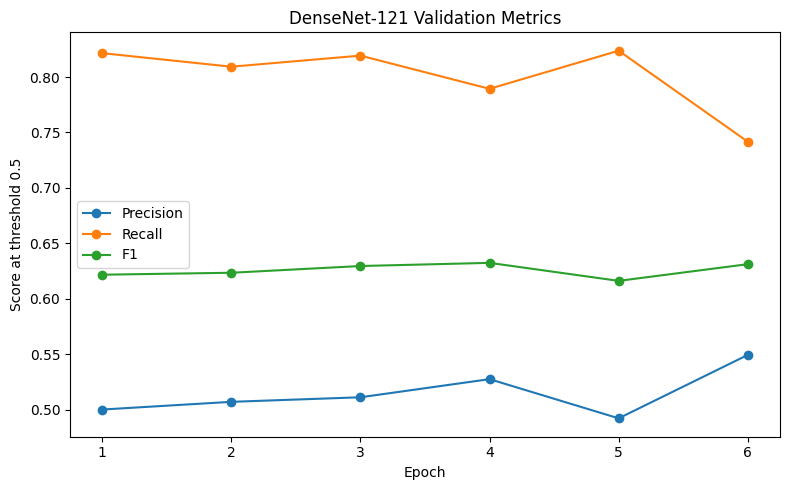

In [15]:
# Load the saved history so this section can be rerun after a kernel restart.
if not HISTORY_PATH.exists():
    raise FileNotFoundError(
        f"Training history not found: {HISTORY_PATH}"
    )

history_df = pd.read_csv(HISTORY_PATH)
display(history_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train",
)
ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted BCE Loss")
ax.set_title("DenseNet-121 Training and Validation Loss")
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "loss_history.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    history_df["epoch"],
    history_df["train_roc_auc"],
    marker="o",
    label="Train ROC-AUC",
)
ax.plot(
    history_df["epoch"],
    history_df["val_roc_auc"],
    marker="o",
    label="Validation ROC-AUC",
)
ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch ({best_epoch})",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("ROC-AUC")
ax.set_title("DenseNet-121 ROC-AUC History")
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "roc_auc_history.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    history_df["epoch"],
    history_df["val_precision"],
    marker="o",
    label="Precision",
)
ax.plot(
    history_df["epoch"],
    history_df["val_recall"],
    marker="o",
    label="Recall",
)
ax.plot(
    history_df["epoch"],
    history_df["val_f1"],
    marker="o",
    label="F1",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Score at threshold 0.5")
ax.set_title("DenseNet-121 Validation Metrics")
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "validation_metrics_history.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


### 3.7 Reload Best Checkpoint and Select the Decision Threshold

The best checkpoint is reloaded before threshold selection. The threshold is selected using validation F1 only; the test set is not used for model or threshold selection.


,metric,value
0,best_epoch,2.000000
1,validation_loss,0.686501
2,validation_roc_auc,0.877712
3,validation_average_precision,0.702913
4,selected_threshold,0.600000
5,validation_accuracy,0.828629
6,validation_balanced_accuracy,0.786795
7,validation_precision_ppv,0.601313
8,validation_recall_sensitivity,0.710643
9,validation_specificity,0.862947


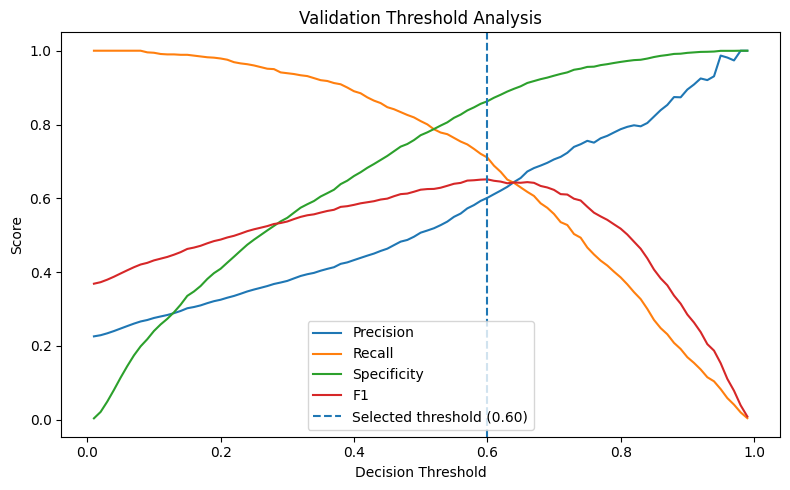

In [16]:
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)
model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

best_epoch = int(best_checkpoint["best_epoch"])
best_val_auc = float(best_checkpoint["best_val_roc_auc"])

saved_history = best_checkpoint.get("history", [])
total_training_minutes = float(
    sum(
        record.get("epoch_minutes", 0.0)
        for record in saved_history
    )
)


@torch.no_grad()
def predict_dataset(model, loader, criterion=None):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_probabilities = []
    all_patient_ids = []

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        targets = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=DEVICE.type == "cuda",
        ):
            logits = model(images).squeeze(1)

            if criterion is not None:
                loss = criterion(logits, targets)
                running_loss += (
                    loss.item() * images.size(0)
                )

        probabilities = torch.sigmoid(logits)

        all_targets.extend(targets.cpu().numpy())
        all_probabilities.extend(
            probabilities.cpu().numpy()
        )
        all_patient_ids.extend(batch["patientId"])

    mean_loss = (
        running_loss / len(loader.dataset)
        if criterion is not None
        else np.nan
    )

    return (
        mean_loss,
        np.asarray(all_targets).astype(int),
        np.asarray(all_probabilities),
        all_patient_ids,
    )


val_loss, val_targets, val_probabilities, val_patient_ids = (
    predict_dataset(
        model,
        val_loader,
        criterion,
    )
)

verified_val_auc = roc_auc_score(
    val_targets,
    val_probabilities,
)

assert np.isclose(
    verified_val_auc,
    best_val_auc,
    atol=1e-6,
)

threshold_rows = []

for threshold in np.linspace(0.01, 0.99, 99):
    metrics = calculate_metrics(
        val_targets,
        val_probabilities,
        threshold=threshold,
    )
    threshold_rows.append({
        "threshold": threshold,
        **metrics,
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]
FINAL_THRESHOLD = float(
    best_threshold_row["threshold"]
)

val_metrics_final = calculate_metrics(
    val_targets,
    val_probabilities,
    threshold=FINAL_THRESHOLD,
)
val_predictions = (
    val_probabilities >= FINAL_THRESHOLD
).astype(int)

validation_predictions_df = pd.DataFrame({
    "patientId": val_patient_ids,
    "target": val_targets,
    "probability": val_probabilities,
    "prediction": val_predictions,
})

threshold_df.to_csv(
    OUTPUT_DIR / "validation_threshold_search.csv",
    index=False,
)
validation_predictions_df.to_csv(
    OUTPUT_DIR / "validation_predictions.csv",
    index=False,
)

validation_summary = pd.DataFrame({
    "metric": [
        "best_epoch",
        "validation_loss",
        "validation_roc_auc",
        "validation_average_precision",
        "selected_threshold",
        "validation_accuracy",
        "validation_balanced_accuracy",
        "validation_precision_ppv",
        "validation_recall_sensitivity",
        "validation_specificity",
        "validation_npv",
        "validation_f1",
        "validation_mcc",
        "validation_brier_score",
        "total_training_minutes",
    ],
    "value": [
        best_epoch,
        val_loss,
        val_metrics_final["roc_auc"],
        val_metrics_final["average_precision"],
        FINAL_THRESHOLD,
        val_metrics_final["accuracy"],
        val_metrics_final["balanced_accuracy"],
        val_metrics_final["precision"],
        val_metrics_final["recall"],
        val_metrics_final["specificity"],
        val_metrics_final["npv"],
        val_metrics_final["f1"],
        val_metrics_final["mcc"],
        val_metrics_final["brier_score"],
        total_training_minutes,
    ],
})

display(validation_summary)

validation_summary.to_csv(
    OUTPUT_DIR / "best_model_validation_summary.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "selected_threshold.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        {
            "threshold": FINAL_THRESHOLD,
            "selection_set": "validation",
            "selection_metric": "F1",
        },
        f,
        indent=2,
    )

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision",
)
ax.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall",
)
ax.plot(
    threshold_df["threshold"],
    threshold_df["specificity"],
    label="Specificity",
)
ax.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1",
)
ax.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=f"Selected threshold ({FINAL_THRESHOLD:.2f})",
)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Validation Threshold Analysis")
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "validation_threshold_analysis.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 4. Test Evaluation

The best model weights and validation-selected decision threshold are frozen before evaluating the test set.


### 4.1 Test Predictions and Metrics


In [17]:
test_loss, test_targets, test_probabilities, test_patient_ids = (
    predict_dataset(
        model,
        test_loader,
        criterion,
    )
)

test_metrics = calculate_metrics(
    test_targets,
    test_probabilities,
    threshold=FINAL_THRESHOLD,
)

test_predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)

test_predictions_df = pd.DataFrame({
    "patientId": test_patient_ids,
    "target": test_targets,
    "probability": test_probabilities,
    "prediction": test_predictions,
})

test_predictions_df = test_predictions_df.merge(
    test_df[
        [
            "patientId",
            "detailed_class",
            "num_pneumonia_boxes",
        ]
    ],
    on="patientId",
    how="left",
    validate="one_to_one",
)

test_predictions_df["error_type"] = np.select(
    [
        (test_predictions_df["target"] == 1)
        & (test_predictions_df["prediction"] == 0),
        (test_predictions_df["target"] == 0)
        & (test_predictions_df["prediction"] == 1),
    ],
    [
        "False Negative",
        "False Positive",
    ],
    default="Correct",
)

test_predictions_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)

final_test_metrics = pd.DataFrame({
    "metric": [
        "test_loss",
        "roc_auc",
        "average_precision_pr_auc",
        "accuracy",
        "balanced_accuracy",
        "precision_ppv",
        "recall_sensitivity",
        "specificity",
        "negative_predictive_value",
        "f1",
        "matthews_correlation_coefficient",
        "brier_score",
        "decision_threshold",
        "true_negative",
        "false_positive",
        "false_negative",
        "true_positive",
    ],
    "value": [
        test_loss,
        test_metrics["roc_auc"],
        test_metrics["average_precision"],
        test_metrics["accuracy"],
        test_metrics["balanced_accuracy"],
        test_metrics["precision"],
        test_metrics["recall"],
        test_metrics["specificity"],
        test_metrics["npv"],
        test_metrics["f1"],
        test_metrics["mcc"],
        test_metrics["brier_score"],
        FINAL_THRESHOLD,
        test_metrics["tn"],
        test_metrics["fp"],
        test_metrics["fn"],
        test_metrics["tp"],
    ],
})

display(final_test_metrics)

final_test_metrics.to_csv(
    OUTPUT_DIR / "test_metrics.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "test_metrics.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        {
            "test_loss": float(test_loss),
            "roc_auc": float(test_metrics["roc_auc"]),
            "average_precision": float(
                test_metrics["average_precision"]
            ),
            "accuracy": float(test_metrics["accuracy"]),
            "balanced_accuracy": float(
                test_metrics["balanced_accuracy"]
            ),
            "precision_ppv": float(
                test_metrics["precision"]
            ),
            "recall_sensitivity": float(
                test_metrics["recall"]
            ),
            "specificity": float(
                test_metrics["specificity"]
            ),
            "negative_predictive_value": float(
                test_metrics["npv"]
            ),
            "f1": float(test_metrics["f1"]),
            "mcc": float(test_metrics["mcc"]),
            "brier_score": float(
                test_metrics["brier_score"]
            ),
            "decision_threshold": float(FINAL_THRESHOLD),
            "tn": int(test_metrics["tn"]),
            "fp": int(test_metrics["fp"]),
            "fn": int(test_metrics["fn"]),
            "tp": int(test_metrics["tp"]),
        },
        f,
        indent=2,
    )


,metric,value
0,test_loss,0.679490
1,roc_auc,0.881840
2,average_precision_pr_auc,0.700388
3,accuracy,0.827130
4,balanced_accuracy,0.790152
5,precision_ppv,0.595978
6,recall_sensitivity,0.722838
7,specificity,0.857465
8,negative_predictive_value,0.914060
9,f1,0.653307


### 4.2 Confusion Matrix


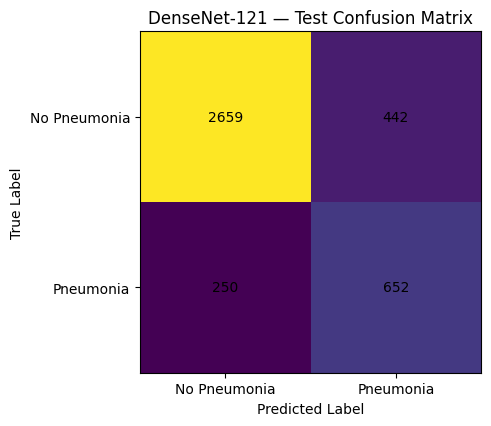

In [18]:
cm = confusion_matrix(
    test_targets,
    test_predictions,
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm)

ax.set_xticks(
    [0, 1],
    labels=["No Pneumonia", "Pneumonia"],
)
ax.set_yticks(
    [0, 1],
    labels=["No Pneumonia", "Pneumonia"],
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("DenseNet-121 — Test Confusion Matrix")

for row in range(2):
    for column in range(2):
        ax.text(
            column,
            row,
            str(cm[row, column]),
            ha="center",
            va="center",
        )

fig.tight_layout()
fig.savefig(
    PLOT_DIR / "test_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


### 4.3 ROC and Precision-Recall Curves


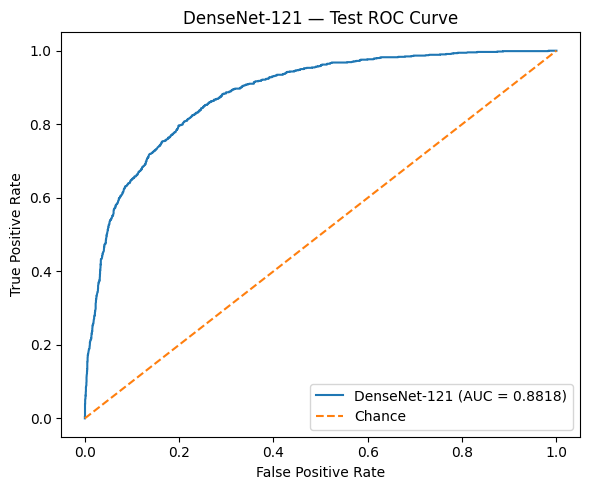

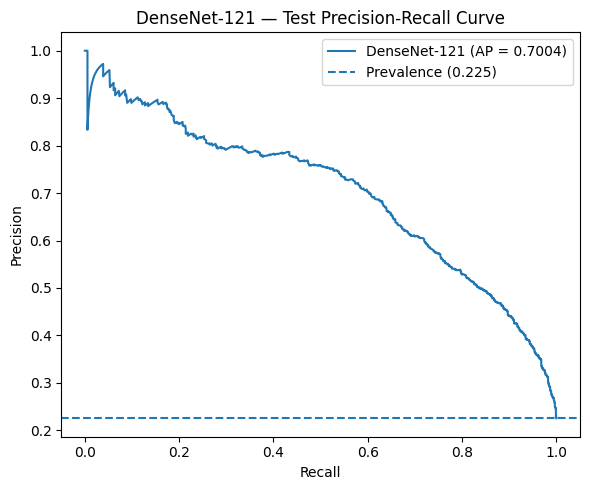

In [19]:
fpr, tpr, _ = roc_curve(
    test_targets,
    test_probabilities,
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    fpr,
    tpr,
    label=(
        f"DenseNet-121 "
        f"(AUC = {test_metrics['roc_auc']:.4f})"
    ),
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance",
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("DenseNet-121 — Test ROC Curve")
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "test_roc_curve.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

pr_precision, pr_recall, _ = precision_recall_curve(
    test_targets,
    test_probabilities,
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    pr_recall,
    pr_precision,
    label=(
        f"DenseNet-121 "
        f"(AP = {test_metrics['average_precision']:.4f})"
    ),
)
ax.axhline(
    test_targets.mean(),
    linestyle="--",
    label=f"Prevalence ({test_targets.mean():.3f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("DenseNet-121 — Test Precision-Recall Curve")
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "test_precision_recall_curve.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


### 4.4 Probability Distribution and Calibration

Predicted probabilities are inspected by true class. The calibration plot and Brier score describe probability calibration; they are not used for model selection.


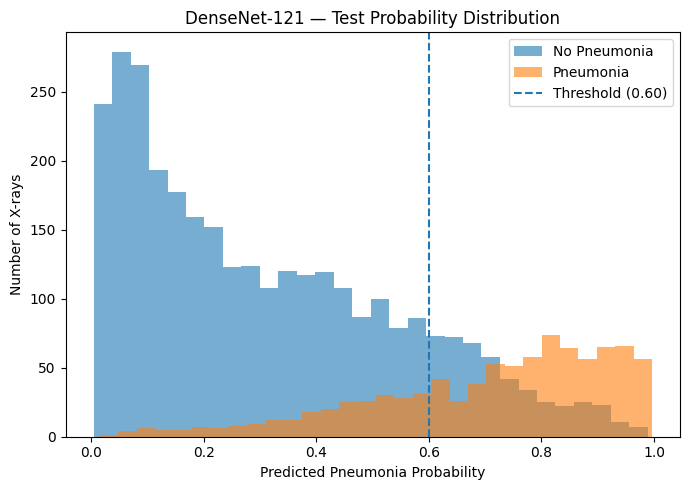

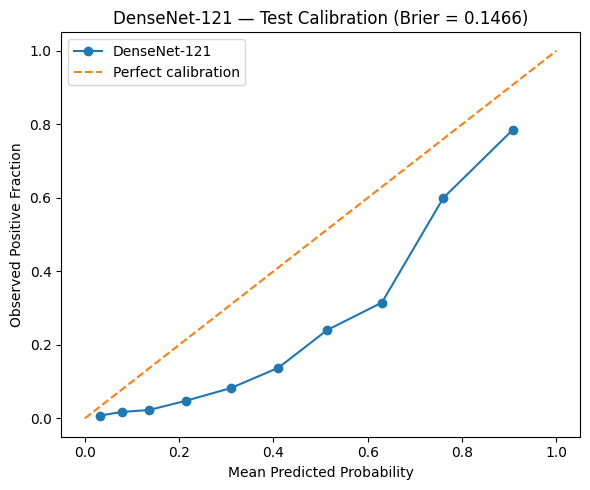

In [20]:
negative_probabilities = test_probabilities[
    test_targets == 0
]
positive_probabilities = test_probabilities[
    test_targets == 1
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(
    negative_probabilities,
    bins=30,
    alpha=0.6,
    label="No Pneumonia",
)
ax.hist(
    positive_probabilities,
    bins=30,
    alpha=0.6,
    label="Pneumonia",
)
ax.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=f"Threshold ({FINAL_THRESHOLD:.2f})",
)
ax.set_xlabel("Predicted Pneumonia Probability")
ax.set_ylabel("Number of X-rays")
ax.set_title("DenseNet-121 — Test Probability Distribution")
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "test_probability_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

fraction_positive, mean_predicted = calibration_curve(
    test_targets,
    test_probabilities,
    n_bins=10,
    strategy="quantile",
)

calibration_df = pd.DataFrame({
    "mean_predicted_probability": mean_predicted,
    "observed_positive_fraction": fraction_positive,
})
calibration_df.to_csv(
    OUTPUT_DIR / "test_calibration.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    label="DenseNet-121",
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Positive Fraction")
ax.set_title(
    "DenseNet-121 — Test Calibration "
    f"(Brier = {test_metrics['brier_score']:.4f})"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "test_calibration_curve.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


### 4.5 Error and Subgroup Analysis

Errors are summarized by the RSNA detailed diagnostic class. This separates false positives among normal X-rays from false positives among abnormal X-rays without pneumonia.


,detailed_class,samples,target_positive,predicted_positive,correct,errors,error_rate
0,Lung Opacity,902,902,652,652,250,0.277162
1,No Lung Opacity / Not Normal,1780,0,435,1345,435,0.244382
2,Normal,1321,0,7,1314,7,0.005299


,error_type,count
0,Correct,3311
1,False Positive,442
2,False Negative,250


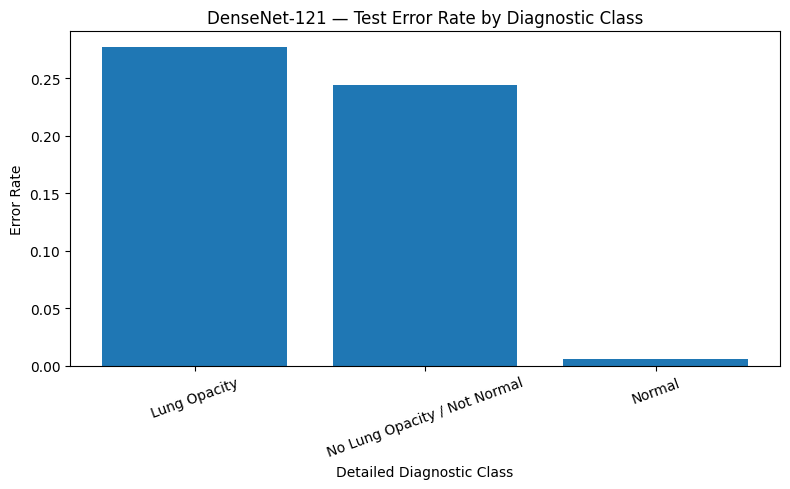

In [21]:
subgroup_rows = []

for class_name, group in test_predictions_df.groupby(
    "detailed_class",
    sort=True,
):
    class_target = group["target"].to_numpy()
    class_prediction = group["prediction"].to_numpy()

    subgroup_rows.append({
        "detailed_class": class_name,
        "samples": len(group),
        "target_positive": int(class_target.sum()),
        "predicted_positive": int(class_prediction.sum()),
        "correct": int(
            (class_target == class_prediction).sum()
        ),
        "errors": int(
            (class_target != class_prediction).sum()
        ),
        "error_rate": float(
            (class_target != class_prediction).mean()
        ),
    })

subgroup_summary = pd.DataFrame(subgroup_rows)
display(subgroup_summary)

subgroup_summary.to_csv(
    OUTPUT_DIR / "test_subgroup_error_summary.csv",
    index=False,
)

error_summary = (
    test_predictions_df["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

display(error_summary)

error_summary.to_csv(
    OUTPUT_DIR / "test_error_summary.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    subgroup_summary["detailed_class"],
    subgroup_summary["error_rate"],
)
ax.set_xlabel("Detailed Diagnostic Class")
ax.set_ylabel("Error Rate")
ax.set_title("DenseNet-121 — Test Error Rate by Diagnostic Class")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(
    PLOT_DIR / "test_error_rate_by_diagnostic_class.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 5. Explainability


### 5.1 Grad-CAM by Prediction Outcome

Grad-CAM is generated from the final DenseNet feature layer. Representative true-positive, true-negative, false-positive, and false-negative test cases are shown when available. Ground-truth opacity boxes are overlaid for pneumonia-positive cases.


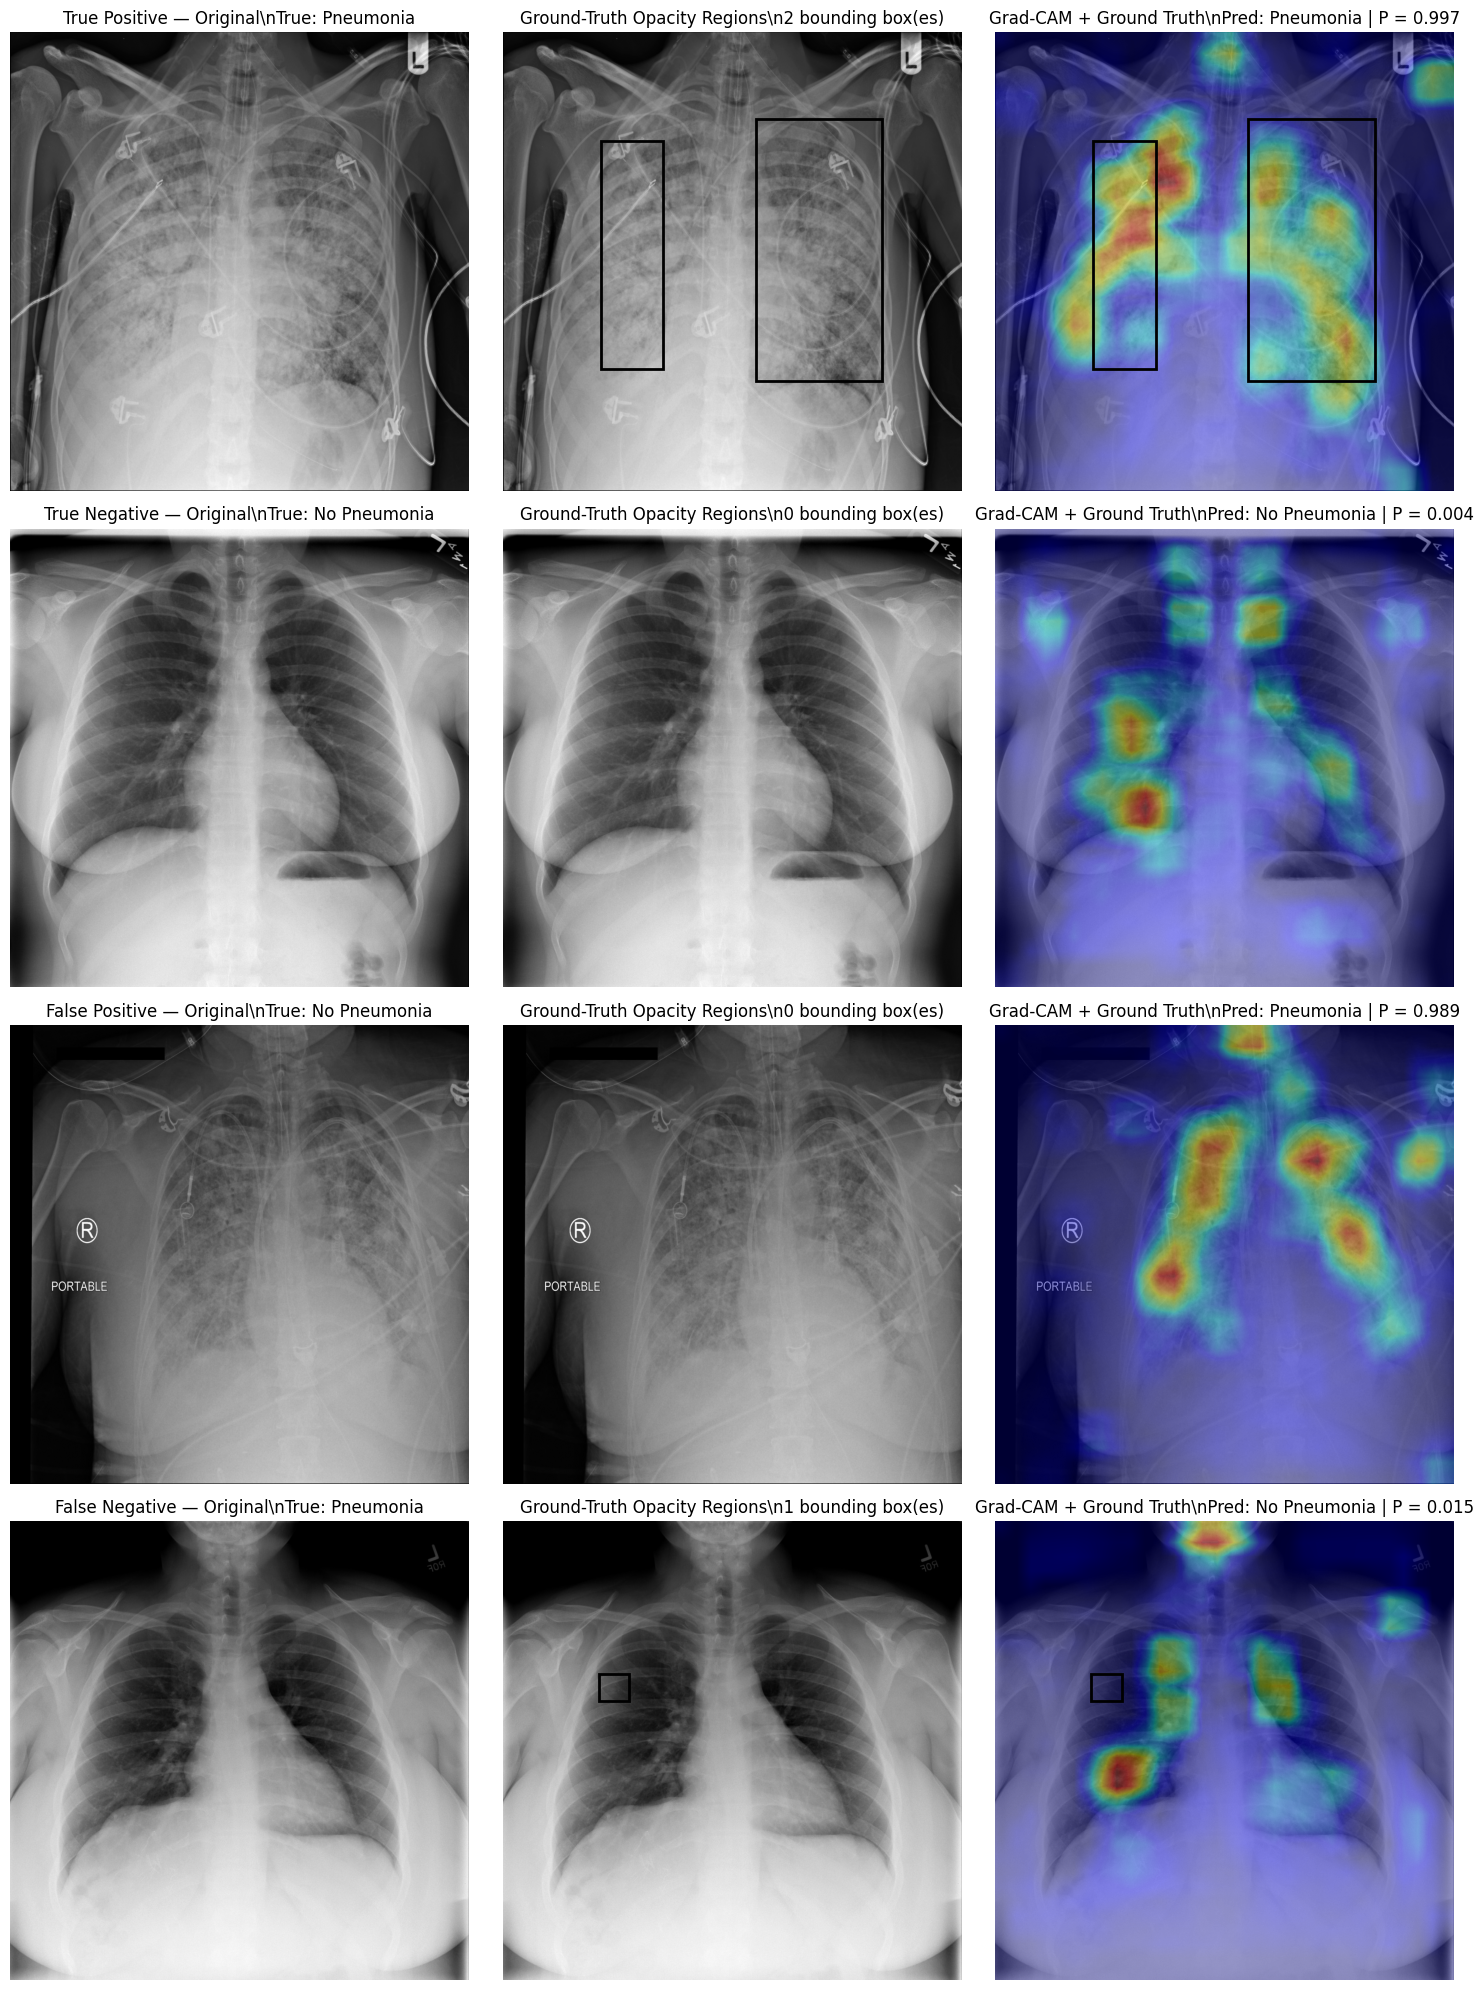

,outcome,patientId,true_label,predicted_probability,decision_threshold,prediction,ground_truth_boxes
0,True Positive,d667579e-aa2d-461e-a869-4799ad466add,1,0.99660,0.6,1,2
1,True Negative,af8b563a-6874-45b6-b1fa-8c047177a7aa,0,0.00399,0.6,0,0
2,False Positive,e6e4c1a3-7efd-4ee3-b955-8e3ed9176972,0,0.98900,0.6,1,0
3,False Negative,2dce719f-1702-406f-a471-03f033f1822a,1,0.01513,0.6,0,1


In [ ]:
def generate_gradcam(model, input_tensor, target_layer):
    activation_storage = {}

    def save_activation(module, inputs, output):
        activation_storage["tensor"] = output
        output.retain_grad()

    handle = target_layer.register_forward_hook(
        save_activation
    )

    try:
        model.eval()
        model.zero_grad(set_to_none=True)

        with torch.enable_grad():
            output = model(input_tensor)
            logit = output.reshape(-1)[0]
            probability = torch.sigmoid(logit).item()
            logit.backward()

        feature_maps = activation_storage.get("tensor")

        if feature_maps is None:
            raise RuntimeError(
                "Grad-CAM activation hook did not capture features."
            )

        gradients = feature_maps.grad

        if gradients is None:
            raise RuntimeError(
                "Grad-CAM gradients were not retained."
            )

        feature_maps = feature_maps.detach()
        gradients = gradients.detach()

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True,
        )

        cam = (
            weights * feature_maps
        ).sum(
            dim=1,
            keepdim=True,
        )

        return F.relu(cam)

    finally:
        handle.remove()


# Reload saved evaluation artifacts when this section is run independently.
TEST_PREDICTIONS_PATH = OUTPUT_DIR / "test_predictions.csv"
THRESHOLD_PATH = OUTPUT_DIR / "selected_threshold.json"

if not TEST_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        "Run the test evaluation once before Grad-CAM."
    )

test_predictions_df = pd.read_csv(TEST_PREDICTIONS_PATH)

if "FINAL_THRESHOLD" not in globals():
    if not THRESHOLD_PATH.exists():
        raise FileNotFoundError(
            f"Selected threshold not found: {THRESHOLD_PATH}"
        )
    with open(THRESHOLD_PATH, "r", encoding="utf-8") as f:
        FINAL_THRESHOLD = float(json.load(f)["threshold"])

# Reload the best weights when this section is run after a kernel restart.
if "model" not in globals():
    weights = DenseNet121_Weights.DEFAULT
    model = densenet121(weights=weights)
    model.classifier = nn.Linear(
        model.classifier.in_features,
        1,
    )
    model = model.to(DEVICE)

best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)
model.load_state_dict(
    best_checkpoint["model_state_dict"]
)
model.eval()

case_conditions = {
    "True Positive": (
        (test_predictions_df["target"] == 1)
        & (test_predictions_df["prediction"] == 1)
    ),
    "True Negative": (
        (test_predictions_df["target"] == 0)
        & (test_predictions_df["prediction"] == 0)
    ),
    "False Positive": (
        (test_predictions_df["target"] == 0)
        & (test_predictions_df["prediction"] == 1)
    ),
    "False Negative": (
        (test_predictions_df["target"] == 1)
        & (test_predictions_df["prediction"] == 0)
    ),
}

selected_cases = []

for outcome, condition in case_conditions.items():
    candidates = test_predictions_df.loc[condition].copy()

    if candidates.empty:
        continue

    # Choose the most confident prediction within each outcome category.
    if outcome in {"True Positive", "False Positive"}:
        selected = candidates.sort_values(
            "probability",
            ascending=False,
        ).iloc[0]
    else:
        selected = candidates.sort_values(
            "probability",
            ascending=True,
        ).iloc[0]

    selected_cases.append((outcome, selected))

if not selected_cases:
    raise RuntimeError(
        "No test cases are available for Grad-CAM visualization."
    )

fig, axes = plt.subplots(
    len(selected_cases),
    3,
    figsize=(15, 5 * len(selected_cases)),
    squeeze=False,
)

gradcam_rows = []

for row_index, (outcome, selected) in enumerate(selected_cases):
    patient_id = selected["patientId"]
    probability = float(selected["probability"])
    true_label = int(selected["target"])
    prediction = int(selected["prediction"])

    metadata_row = test_df.loc[
        test_df["patientId"] == patient_id
    ].iloc[0]

    image_path = metadata_row["image_path"]

    ds = pydicom.dcmread(image_path)
    original = ds.pixel_array.astype(np.float32)

    bits_stored = int(getattr(ds, "BitsStored", 8))
    scale = float((2 ** bits_stored) - 1)

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        original = scale - original

    original = np.clip(
        original / scale,
        0.0,
        1.0,
    )

    input_image = eval_transform(original)
    input_tensor = input_image.unsqueeze(0).to(DEVICE)

    cam = generate_gradcam(
        model,
        input_tensor,
        model.features.norm5,
    )

    cam = F.interpolate(
        cam,
        size=original.shape,
        mode="bilinear",
        align_corners=False,
    )

    cam = cam[0, 0].detach().cpu().numpy()

    cam_min = cam.min()
    cam_max = cam.max()

    if cam_max > cam_min:
        cam = (cam - cam_min) / (cam_max - cam_min)
    else:
        cam = np.zeros_like(cam)

    patient_boxes = labels_df[
        (labels_df["patientId"] == patient_id)
        & (labels_df["Target"] == 1)
    ][["x", "y", "width", "height"]].dropna()

    true_text = (
        "Pneumonia"
        if true_label == 1
        else "No Pneumonia"
    )
    prediction_text = (
        "Pneumonia"
        if prediction == 1
        else "No Pneumonia"
    )

    axes[row_index, 0].imshow(
        original,
        cmap="gray",
    )
    axes[row_index, 0].set_title(
        f"{outcome} — Original\\n"
        f"True: {true_text}"
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(
        original,
        cmap="gray",
    )

    for _, box in patient_boxes.iterrows():
        axes[row_index, 1].add_patch(
            Rectangle(
                (box["x"], box["y"]),
                box["width"],
                box["height"],
                fill=False,
                linewidth=2,
            )
        )

    axes[row_index, 1].set_title(
        "Ground-Truth Opacity Regions\\n"
        f"{len(patient_boxes)} bounding box(es)"
    )
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(
        original,
        cmap="gray",
    )
    axes[row_index, 2].imshow(
        cam,
        cmap="jet",
        alpha=0.40,
        vmin=0,
        vmax=1,
    )

    for _, box in patient_boxes.iterrows():
        axes[row_index, 2].add_patch(
            Rectangle(
                (box["x"], box["y"]),
                box["width"],
                box["height"],
                fill=False,
                linewidth=2,
            )
        )

    axes[row_index, 2].set_title(
        "Grad-CAM + Ground Truth\\n"
        f"Pred: {prediction_text} | P = {probability:.3f}"
    )
    axes[row_index, 2].axis("off")

    gradcam_rows.append({
        "outcome": outcome,
        "patientId": patient_id,
        "true_label": true_label,
        "predicted_probability": probability,
        "decision_threshold": FINAL_THRESHOLD,
        "prediction": prediction,
        "ground_truth_boxes": len(patient_boxes),
    })

fig.tight_layout()
fig.savefig(
    PLOT_DIR / "gradcam_prediction_outcomes.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

gradcam_summary = pd.DataFrame(gradcam_rows)
display(gradcam_summary)

gradcam_summary.to_csv(
    OUTPUT_DIR / "gradcam_prediction_outcomes.csv",
    index=False,
)


## 6. Saved Artifacts

The saved checkpoints, training history, threshold, predictions, metrics, tables, and figures allow the experiment to be inspected or evaluated later without repeating model training.


In [23]:
artifact_rows = []

for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        artifact_rows.append({
            "file": str(path.relative_to(OUTPUT_DIR)),
            "size_mb": path.stat().st_size / (1024 ** 2),
        })

artifact_summary = pd.DataFrame(artifact_rows)
display(artifact_summary)

print(f"Artifacts saved under: {OUTPUT_DIR}")


archive_path = shutil.make_archive(
    str(OUTPUT_DIR),
    "zip",
    root_dir=OUTPUT_DIR,
)

print(f"Download archive: {archive_path}")


,file,size_mb
0,best_model_validation_summary.csv,0.000552
1,class_weight_summary.csv,0.000105
2,gradcam_prediction_outcomes.csv,0.000358
3,models/densenet121_best.pth,80.481786
4,models/densenet121_last.pth,80.483006
5,plots/gradcam_prediction_outcomes.png,5.990334
6,plots/loss_history.png,0.085066
7,plots/roc_auc_history.png,0.084715
8,plots/test_calibration_curve.png,0.087201
9,plots/test_confusion_matrix.png,0.041537


Artifacts saved under: /kaggle/working/rsna_outputs/cnn
Download archive: /kaggle/working/rsna_outputs/cnn.zip
